# Stage 11B — Protocol-Conformant Reacquisition and Patient-Grouping Repair

This independent notebook inherits the sealed Stage 10 role registry, the completed Stage 11 v0.2 record, and the Stage 11A cause/action registry. It repairs only the five preassigned breast-ultrasound **development** datasets.

Stage 11A explicitly froze `may_fit_source_axis_in_stage11b = False` for all five datasets. Therefore Stage 11B may: (i) corroborate and repair the BUS-BRA patient grouping using official release evidence and author code; and (ii) recheck the four official provider routes under metadata/manifest-only transport gates. It may not fit a source axis, evaluate recoverability or transfer edges, fit DDO2, enter Stage 12, substitute a dataset, or access any locked-blind asset.

If one or more repairs pass, this notebook seals an exact development-only handoff to a separate Stage 11C acquisition/source-gate run. Provider assets whose Stage 11A action registry forbids download are never downloaded here, even if their metadata route becomes live.

In [8]:
# @title 11B-0. Mount Drive, verify sealed parents, freeze scope, and seal the repair protocol
import hashlib
import io
import json
import os
import re
import shutil
import time
import zipfile
from datetime import datetime, timezone
from pathlib import Path
from urllib.parse import quote, urlparse

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ModuleNotFoundError:
    pass

TEST_MODE = bool(os.environ.get("CDO_STAGE11B_TEST_MODE") == "1" and not IN_COLAB)
DEFAULT_PROJECT_ROOT = Path("/content/drive/MyDrive/Cross-Modal_Diagnostic_Observability") if IN_COLAB else Path("/tmp/Cross-Modal_Diagnostic_Observability")
PROJECT_ROOT = Path(os.environ.get("CDO_PROJECT_ROOT", str(DEFAULT_PROJECT_ROOT)))
CODE_ROOT = PROJECT_ROOT / "05_Code" / "Cross_Modal"
CROSS_MODAL_ROOT = PROJECT_ROOT / "06_Data_Records" / "Cross_Modal"

STAGE10_ROOT = CROSS_MODAL_ROOT / "Stage10_Preassigned_Development_And_Locked_Blind_Registry_v0.1"
STAGE11_ROOT = CROSS_MODAL_ROOT / "Stage11_Development_Extension_Acquisition_And_Source_Gates_v0.2"
STAGE11A_ROOT = CROSS_MODAL_ROOT / "Stage11A_Hold_And_Unavailable_Cause_Audit_v0.1"
STAGE11B_ROOT = CROSS_MODAL_ROOT / "Stage11B_Protocol_Conformant_Reacquisition_And_Patient_Grouping_Repair_v0.1"

PROTOCOL_ROOT = STAGE11B_ROOT / "00_Protocol"
BUS_BRA_ROOT = STAGE11B_ROOT / "01_BUS_BRA_Grouping_Repair"
TRANSPORT_ROOT = STAGE11B_ROOT / "02_Official_Transport_Recheck"
ADJUDICATION_ROOT = STAGE11B_ROOT / "03_Frozen_Repair_Adjudication"
QUALITY_ROOT = STAGE11B_ROOT / "04_Independent_Validity"
RESULT_ROOT = STAGE11B_ROOT / "05_Results"
for directory in [CODE_ROOT, PROTOCOL_ROOT, BUS_BRA_ROOT, TRANSPORT_ROOT, ADJUDICATION_ROOT, QUALITY_ROOT, RESULT_ROOT]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PATH = CODE_ROOT / "CrossModal_Stage11B_Protocol_Conformant_Reacquisition_And_Patient_Grouping_Repair_v0.1.ipynb"
STAGE10_ROLE_PATH = STAGE10_ROOT / "01_Role_Registry" / "Stage10_Frozen_Dataset_Acquisition_Role_Registry_v0.1.csv"
STAGE11_PROTOCOL_PATH = STAGE11_ROOT / "00_Protocol" / "Stage11_Development_Acquisition_And_Source_Gate_Protocol_Seal_v0.2.json"
STAGE11_ACQUISITION_PATH = STAGE11_ROOT / "01_Official_Acquisition" / "Stage11_Development_Dataset_Acquisition_Status_v0.2.csv"
STAGE11_BUS_BRA_MANIFEST_PATH = STAGE11_ROOT / "02_Harmonised_Manifests" / "BUS_BRA_2024_Harmonised_Development_Manifest_v0.2.csv"
STAGE11_SOURCE_SUMMARY_PATH = STAGE11_ROOT / "04_Frozen_Source_Axes" / "Stage11_Source_Recoverability_Summary_v0.2.csv"
STAGE11_FINAL_PATH = STAGE11_ROOT / "06_Results" / "Stage11_Development_Acquisition_And_Source_Gates_Complete_v0.2.json"
STAGE11A_PROTOCOL_PATH = STAGE11A_ROOT / "00_Protocol" / "Stage11A_Hold_Cause_Audit_Protocol_Seal_v0.1.json"
STAGE11A_GROUPING_PATH = STAGE11A_ROOT / "01_Inherited_And_Official_Evidence" / "Stage11A_BUS_BRA_Patient_Grouping_Consistency_Audit_v0.1.csv"
STAGE11A_CAUSE_PATH = STAGE11A_ROOT / "02_Cause_Classification" / "Stage11A_Dataset_Hold_Cause_Classification_v0.1.csv"
STAGE11A_ACTION_PATH = STAGE11A_ROOT / "03_Frozen_Remediation_Actions" / "Stage11A_Frozen_Remediation_Action_Registry_v0.1.csv"
STAGE11A_FINAL_PATH = STAGE11A_ROOT / "05_Results" / "Stage11A_Hold_And_Unavailable_Cause_Audit_Complete_v0.1.json"

PROTOCOL_SEAL_PATH = PROTOCOL_ROOT / "Stage11B_Repair_Protocol_Seal_v0.1.json"
PARENT_COMMITMENT_PATH = PROTOCOL_ROOT / "Stage11B_Parent_Input_Commitment_v0.1.csv"
REQUEST_AUDIT_PATH = TRANSPORT_ROOT / "Stage11B_Development_Only_Request_Audit_v0.1.csv"
ASSET_LEDGER_PATH = BUS_BRA_ROOT / "Stage11B_Official_Development_Asset_Checksum_Ledger_v0.1.csv"
BUS_BRA_PROOF_PATH = BUS_BRA_ROOT / "Stage11B_BUS_BRA_Patient_Grouping_Proof_Criteria_v0.1.csv"
BUS_BRA_MANIFEST_PATH = BUS_BRA_ROOT / "Stage11B_BUS_BRA_Patient_Grouped_Development_Manifest_v0.1.csv"
TRANSPORT_RECHECK_PATH = TRANSPORT_ROOT / "Stage11B_Official_Provider_Transport_Recheck_v0.1.csv"
REPAIR_REGISTRY_PATH = ADJUDICATION_ROOT / "Stage11B_Frozen_Repair_Outcome_Registry_v0.1.csv"
STAGE11C_HANDOFF_PATH = ADJUDICATION_ROOT / "Stage11B_Development_Only_Stage11C_Handoff_v0.1.csv"
VALIDITY_PATH = QUALITY_ROOT / "Stage11B_Independent_Validity_Checks_v0.1.csv"
REPORT_PATH = RESULT_ROOT / "Stage11B_Repair_And_Reacquisition_Report_v0.1.md"
FIGURE_PATH = RESULT_ROOT / "Stage11B_Repair_Status_v0.1.png"
OUTPUT_MANIFEST_PATH = RESULT_ROOT / "Stage11B_Output_Integrity_Manifest_v0.1.csv"
RUNTIME_STATE_PATH = RESULT_ROOT / "Stage11B_Runtime_State_v0.1.json"
FINAL_RECORD_PATH = RESULT_ROOT / "Stage11B_Protocol_Conformant_Repair_Complete_v0.1.json"

EXPECTED_STAGE10_ROLE_HASH = "cc0b56178eecee123d8c6fa99824018b18aae79679c6620edc7e5ebcc9018bc3"
EXPECTED_STAGE11_FINAL_HASH = "bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dcbfc2ca079e1cbb8889"
EXPECTED_STAGE11_PROTOCOL_SEAL = "fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b6865e9d9f4af59bbcd"
EXPECTED_STAGE11_SOURCE_HASH = "2b907cc8ebbef7c6d3fc206b7c0a3067ad3d503594f2323d9f19f2a2c3a91af6"
EXPECTED_STAGE11A_FINAL_HASH = "9858f91de0e78863281c74488f1002641d2d968de319fb3f239c406e26c69114"
EXPECTED_STAGE11A_PROTOCOL_SEAL = "e8196fcdb9c05c5b04e9bbf8ac3b520991e51114d684ef3484b36c5fbad1cd44"
EXPECTED_STAGE11A_ACTION_HASH = "8738b3f470e33a8de28cca1612e9595608660d6c05f1eef7e16f6f0a6b0c452b"
EXPECTED_STAGE11A_CAUSE_HASH = "1303c704d20f57ed9a05be03e0525a34c5d40624bffdece85dccb5077d99ca2d"
EXPECTED_STAGE11_BUS_BRA_MANIFEST_HASH = "6aa5b1c6a09f146265061f411c8d8e6f617040c3a3f6f769e4a67466082b9e26"
MAXIMUM_NEW_STAGE11B_BYTES = 100 * 1024 * 1024

def utc_now():
    return datetime.now(timezone.utc).isoformat()

def sha256_bytes(raw):
    return hashlib.sha256(raw).hexdigest()

def sha256_file(path, block_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            block = handle.read(block_size)
            if not block:
                break
            digest.update(block)
    return digest.hexdigest()

def sha256_json(payload):
    raw = json.dumps(payload, sort_keys=True, separators=(",", ":"), ensure_ascii=False).encode("utf-8")
    return sha256_bytes(raw)

def canonical_csv_text(frame):
    return frame.to_csv(index=False, lineterminator="\n", float_format="%.12g")

def atomic_text(path, text):
    path = Path(path)
    temporary = Path(str(path) + ".tmp")
    temporary.write_text(text, encoding="utf-8")
    os.replace(temporary, path)

def atomic_json(path, payload):
    atomic_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def write_progress_csv(path, frame):
    text = canonical_csv_text(frame)
    if FINAL_RECORD_PATH.is_file():
        assert Path(path).is_file() and Path(path).read_text(encoding="utf-8") == text
    else:
        atomic_text(path, text)

def write_immutable_text(path, text):
    path = Path(path)
    if path.is_file():
        assert path.read_text(encoding="utf-8") == text, f"Existing immutable output differs: {path}"
    else:
        path.write_text(text, encoding="utf-8")

def write_immutable_csv(path, frame):
    write_immutable_text(path, canonical_csv_text(frame))

def write_immutable_json(path, payload):
    write_immutable_text(path, json.dumps(payload, indent=2, ensure_ascii=False) + "\n")

def verify_self_hashed_json(path, hash_field, expected=None):
    payload = json.loads(Path(path).read_text(encoding="utf-8"))
    claim = payload.get(hash_field)
    without_claim = dict(payload)
    without_claim.pop(hash_field, None)
    assert claim == sha256_json(without_claim), f"Self-hash mismatch: {path}"
    if expected is not None:
        assert claim == expected, f"Unexpected {hash_field}: {path}"
    return payload

def normalised_notebook_source_sha256(path):
    notebook = json.loads(Path(path).read_text(encoding="utf-8"))
    source_payload = []
    for cell in notebook.get("cells", []):
        if cell.get("cell_type") not in {"code", "markdown"}:
            continue
        source = cell.get("source", [])
        source = "".join(source) if isinstance(source, list) else str(source)
        source_payload.append({"cell_type": cell["cell_type"], "source": source.replace("\r\n", "\n")})
    return sha256_json(source_payload)

required_parents = [
    STAGE10_ROLE_PATH, STAGE11_PROTOCOL_PATH, STAGE11_ACQUISITION_PATH,
    STAGE11_BUS_BRA_MANIFEST_PATH, STAGE11_SOURCE_SUMMARY_PATH, STAGE11_FINAL_PATH,
    STAGE11A_PROTOCOL_PATH, STAGE11A_GROUPING_PATH, STAGE11A_CAUSE_PATH,
    STAGE11A_ACTION_PATH, STAGE11A_FINAL_PATH, NOTEBOOK_PATH,
]
assert all(path.is_file() for path in required_parents), "A required Stage 10/11/11A input or the frozen notebook is missing."

stage11_final = verify_self_hashed_json(STAGE11_FINAL_PATH, "final_record_sha256", EXPECTED_STAGE11_FINAL_HASH)
stage11_protocol = verify_self_hashed_json(STAGE11_PROTOCOL_PATH, "seal_sha256", EXPECTED_STAGE11_PROTOCOL_SEAL)
stage11a_final = verify_self_hashed_json(STAGE11A_FINAL_PATH, "final_record_sha256", EXPECTED_STAGE11A_FINAL_HASH)
stage11a_protocol = verify_self_hashed_json(STAGE11A_PROTOCOL_PATH, "seal_sha256", EXPECTED_STAGE11A_PROTOCOL_SEAL)
assert sha256_file(STAGE10_ROLE_PATH) == EXPECTED_STAGE10_ROLE_HASH
assert sha256_file(STAGE11_SOURCE_SUMMARY_PATH) == EXPECTED_STAGE11_SOURCE_HASH
assert sha256_file(STAGE11_BUS_BRA_MANIFEST_PATH) == EXPECTED_STAGE11_BUS_BRA_MANIFEST_HASH
assert sha256_file(STAGE11A_ACTION_PATH) == EXPECTED_STAGE11A_ACTION_HASH
assert sha256_file(STAGE11A_CAUSE_PATH) == EXPECTED_STAGE11A_CAUSE_HASH

role_registry = pd.read_csv(STAGE10_ROLE_PATH)
action_registry = pd.read_csv(STAGE11A_ACTION_PATH)
development_ids = tuple(action_registry["dataset_id"].astype(str))
blind_ids = tuple(role_registry.loc[role_registry["role_frozen_before_label_access"].eq("LOCKED_BLIND_TEST"), "dataset_id"].astype(str))
assert len(development_ids) == 5 and len(blind_ids) == 3 and set(development_ids).isdisjoint(blind_ids)
assert not action_registry["may_fit_source_axis_in_stage11b"].astype(str).str.lower().eq("true").any()
assert not action_registry["may_access_locked_blind"].astype(str).str.lower().eq("true").any()
assert not action_registry["may_substitute_dataset"].astype(str).str.lower().eq("true").any()
assert not action_registry["may_enter_stage12"].astype(str).str.lower().eq("true").any()

REPLAY_MODE = FINAL_RECORD_PATH.is_file()
notebook_source_hash = normalised_notebook_source_sha256(NOTEBOOK_PATH)
analysis_spec = {
    "scope": "repair only the five preassigned DEVELOPMENT_EXTENSION datasets under the Stage11A action registry",
    "bus_bra_rule": "promote numeric prefix to a development patient group only if official release patient/image counts, complete prefix coverage, released labels, released fold assignments, and official author-code links all reconcile",
    "provider_rule": "four provider-held datasets receive bounded official metadata/manifest transport rechecks only; no image, archive, or label download is authorised by Stage11A",
    "handoff_rule": "a passing repair may authorise only an exact Stage11C development handoff; Stage11B itself never fits or evaluates a source axis",
    "no_model_boundary": "no embedding, source fit, source recoverability, transfer edge, threshold tuning, target refit, DDO2 fit, Stage12, or blind validation",
    "locked_blind_firewall": "no locked-blind endpoint, metadata, image, label, archive, prediction, or result request",
    "substitution_rule": "no dataset substitution, role reassignment, or mirror",
}
protocol_payload = {
    "stage": "Stage11B",
    "version": "v0.1",
    "parent_stage11_final_record_sha256": EXPECTED_STAGE11_FINAL_HASH,
    "parent_stage11a_final_record_sha256": EXPECTED_STAGE11A_FINAL_HASH,
    "parent_stage11a_action_registry_sha256": EXPECTED_STAGE11A_ACTION_HASH,
    "parent_role_registry_sha256": EXPECTED_STAGE10_ROLE_HASH,
    "notebook_source_sha256": notebook_source_hash,
    "analysis_spec": analysis_spec,
    "development_dataset_ids": list(development_ids),
    "locked_blind_dataset_ids_sha256": sha256_json(sorted(blind_ids)),
    "sealed_utc": utc_now(),
}
protocol_payload["seal_sha256"] = sha256_json(protocol_payload)
if PROTOCOL_SEAL_PATH.is_file():
    protocol_seal = verify_self_hashed_json(PROTOCOL_SEAL_PATH, "seal_sha256")
    assert protocol_seal["analysis_spec"] == analysis_spec
    assert protocol_seal["notebook_source_sha256"] == notebook_source_hash
else:
    write_immutable_json(PROTOCOL_SEAL_PATH, protocol_payload)
    protocol_seal = verify_self_hashed_json(PROTOCOL_SEAL_PATH, "seal_sha256")

parent_paths = [
    STAGE10_ROLE_PATH, STAGE11_PROTOCOL_PATH, STAGE11_ACQUISITION_PATH,
    STAGE11_BUS_BRA_MANIFEST_PATH, STAGE11_SOURCE_SUMMARY_PATH, STAGE11_FINAL_PATH,
    STAGE11A_PROTOCOL_PATH, STAGE11A_GROUPING_PATH, STAGE11A_CAUSE_PATH,
    STAGE11A_ACTION_PATH, STAGE11A_FINAL_PATH,
]
parent_commitment = pd.DataFrame([{
    "relative_path": str(path.relative_to(PROJECT_ROOT)),
    "sha256": sha256_file(path),
    "bytes": path.stat().st_size,
} for path in parent_paths])
write_progress_csv(PARENT_COMMITMENT_PATH, parent_commitment)

runtime_state = {
    "stage": "Stage11B", "replay_mode": REPLAY_MODE, "test_mode": TEST_MODE,
    "external_requests_made": False, "locked_blind_assets_touched": False,
    "source_axes_fitted": False, "stage12_authorised": False,
    "last_updated_utc": utc_now(),
}
if not REPLAY_MODE:
    atomic_json(RUNTIME_STATE_PATH, runtime_state)
print("Development / locked-blind datasets:", len(development_ids), "/", len(blind_ids))
print("Replay mode / source fit authorised in Stage11B:", REPLAY_MODE, "/", False)
print("Stage11B protocol seal:", protocol_seal["seal_sha256"])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Development / locked-blind datasets: 5 / 3
Replay mode / source fit authorised in Stage11B: True / False
Stage11B protocol seal: f09e2b0d9505bded7329d9b380c098542cc9450b6e16d695295228da18ac67eb


In [9]:
# @title 11B-1. Enforce the frozen action registry and create a typed development-only request firewall
if TEST_MODE:
    requests = None
else:
    import requests

def as_bool(value):
    if isinstance(value, (bool, np.bool_)):
        return bool(value)
    return str(value).strip().lower() == "true"

expected_actions = {
    "BUS_BRA_2024": "CORROBORATE_NUMERIC_PREFIX_WITH_RELEASED_DOCUMENTATION_OR_AUTHOR_CODE_THEN_REBUILD_PATIENT_GROUPED_MANIFEST_AND_RERUN_SOURCE_GATE",
    "BUSI_WHU_2025_V3": "RETRY_ONLY_THE_PREDECLARED_OFFICIAL_PROVIDER_ROUTES_IN_A_SEPARATE_TRANSPORT_REPAIR",
    "BREAST_LESIONS_USG_2024": "RETRY_OFFICIAL_TCIA_IMAGE_TRANSPORT_OR_PROVIDER_MANIFEST_ONLY_NO_MIRROR_THEN_JOIN_TO_ALREADY_RELEASED_CLINICAL_METADATA",
    "BUS_UCLM_2025_V3": "RETRY_ONLY_THE_PREDECLARED_OFFICIAL_PROVIDER_ROUTES_IN_A_SEPARATE_TRANSPORT_REPAIR",
    "RODRIGUES_BUI_2017": "RETRY_ONLY_THE_PREDECLARED_OFFICIAL_PROVIDER_ROUTES_IN_A_SEPARATE_TRANSPORT_REPAIR",
}
assert dict(zip(action_registry["dataset_id"], action_registry["permitted_stage11b_action"])) == expected_actions
download_permission = dict(zip(action_registry["dataset_id"], action_registry["may_download_preassigned_development_assets_in_stage11b"].map(as_bool)))
assert download_permission == {
    "BUS_BRA_2024": True, "BUSI_WHU_2025_V3": False, "BREAST_LESIONS_USG_2024": False,
    "BUS_UCLM_2025_V3": False, "RODRIGUES_BUI_2017": False,
}

ALLOWED_HOSTS = {
    "BUS_BRA_2024": {"zenodo.org", "files.zenodo.org", "github.com", "raw.githubusercontent.com"},
    "BUSI_WHU_2025_V3": {"api.mendeley.com", "api.data.mendeley.com", "data.mendeley.com"},
    "BREAST_LESIONS_USG_2024": {"services.cancerimagingarchive.net", "nbia.cancerimagingarchive.net", "www.cancerimagingarchive.net", "cancerimagingarchive.net"},
    "BUS_UCLM_2025_V3": {"api.mendeley.com", "api.data.mendeley.com", "data.mendeley.com"},
    "RODRIGUES_BUI_2017": {"api.mendeley.com", "api.data.mendeley.com", "data.mendeley.com"},
}
blind_tokens = {str(value).lower() for value in blind_ids}
for column in ["persistent_id", "official_landing_url"]:
    blind_tokens.update(str(value).lower() for value in role_registry.loc[role_registry["dataset_id"].astype(str).isin(blind_ids), column].dropna())

REQUEST_ROWS = []
ASSET_ROWS = []
SESSION = None if TEST_MODE else requests.Session()
if SESSION is not None:
    SESSION.headers.update({"User-Agent": "CDO-Stage11B/0.1 protocol-conformant-repair", "Accept": "*/*"})

def assert_request_authorised(dataset_id, url, request_scope):
    assert dataset_id in development_ids
    parsed = urlparse(str(url))
    assert parsed.scheme == "https"
    assert parsed.netloc.lower() in ALLOWED_HOSTS[dataset_id], f"Unapproved host: {parsed.netloc}"
    lowered = str(url).lower()
    assert not any(token and token in lowered for token in blind_tokens), "Locked-blind request token blocked."
    if request_scope == "DEVELOPMENT_ASSET_DOWNLOAD":
        assert download_permission[dataset_id], f"Stage11A did not authorise asset download for {dataset_id}"
    else:
        assert request_scope == "METADATA_OR_MANIFEST_ONLY"

def bounded_request(dataset_id, route_kind, url, *, expect_json=False, headers=None, attempts=2, max_bytes=2_000_000):
    assert_request_authorised(dataset_id, url, "METADATA_OR_MANIFEST_ONLY")
    last_error = ""
    for attempt in range(1, attempts + 1):
        started = time.time()
        status = 0
        content_type = ""
        resolved_host = ""
        raw = b""
        try:
            response = SESSION.get(url, headers=headers or {}, timeout=(20, 90), allow_redirects=False, stream=True)
            status = int(response.status_code)
            content_type = str(response.headers.get("Content-Type", ""))
            resolved_host = urlparse(response.url).netloc.lower()
            assert resolved_host in ALLOWED_HOSTS[dataset_id]
            for block in response.iter_content(chunk_size=65536):
                if block:
                    raw += block
                    if len(raw) >= max_bytes:
                        raw = raw[:max_bytes]
                        break
            payload = None
            json_valid = False
            if raw and (expect_json or "json" in content_type.lower()):
                try:
                    payload = json.loads(raw.decode("utf-8"))
                    json_valid = True
                except Exception:
                    payload = None
            file_count = 0
            if isinstance(payload, list):
                file_count = len(payload)
            elif isinstance(payload, dict):
                for key in ["entries", "files", "results"]:
                    if isinstance(payload.get(key), list):
                        file_count = len(payload[key])
                        break
            REQUEST_ROWS.append({
                "dataset_id": dataset_id, "route_kind": route_kind, "request_url": str(url),
                "request_scope": "METADATA_OR_MANIFEST_ONLY", "status_code": status,
                "resolved_host": resolved_host, "content_type": content_type,
                "response_type": "JSON" if json_valid else ("EMPTY" if not raw else "NON_JSON"),
                "json_valid": json_valid, "file_or_series_count": file_count,
                "redirect_location_host": urlparse(response.headers.get("Location", "")).netloc.lower(),
                "response_prefix_sha256": sha256_bytes(raw[:4096]), "bytes_read": len(raw),
                "attempt": attempt, "elapsed_seconds": time.time() - started,
                "locked_blind_request": False, "error_class": "" if status < 400 else f"HTTP_{status}",
            })
            return payload, REQUEST_ROWS[-1]
        except Exception as exc:
            last_error = f"{type(exc).__name__}: {exc}"
            REQUEST_ROWS.append({
                "dataset_id": dataset_id, "route_kind": route_kind, "request_url": str(url),
                "request_scope": "METADATA_OR_MANIFEST_ONLY", "status_code": status,
                "resolved_host": resolved_host, "content_type": content_type, "response_type": "ERROR",
                "json_valid": False, "file_or_series_count": 0, "redirect_location_host": "",
                "response_prefix_sha256": sha256_bytes(raw[:4096]), "bytes_read": len(raw),
                "attempt": attempt, "elapsed_seconds": time.time() - started,
                "locked_blind_request": False, "error_class": last_error[:240],
            })
            if attempt < attempts:
                time.sleep(2 ** (attempt - 1))
                continue
    return None, REQUEST_ROWS[-1]

def download_development_asset(dataset_id, asset_kind, url, destination, expected_size=None, checksum_type="", checksum_value=""):
    assert_request_authorised(dataset_id, url, "DEVELOPMENT_ASSET_DOWNLOAD")
    destination = Path(destination)
    destination.parent.mkdir(parents=True, exist_ok=True)
    started = time.time()
    response = SESSION.get(url, timeout=(20, 300), stream=True, allow_redirects=True)
    response.raise_for_status()
    resolved_host = urlparse(response.url).netloc.lower()
    assert resolved_host in ALLOWED_HOSTS[dataset_id], f"Unapproved redirected asset host: {resolved_host}"
    temporary = Path(str(destination) + ".part")
    with temporary.open("wb") as handle:
        for block in response.iter_content(chunk_size=1024 * 1024):
            if block:
                handle.write(block)
    os.replace(temporary, destination)
    if expected_size not in [None, "", -1]:
        assert destination.stat().st_size == int(expected_size)
    actual_sha256 = sha256_file(destination)
    repository_checksum_match = None
    if checksum_value:
        if str(checksum_type).lower() == "md5":
            digest = hashlib.md5(destination.read_bytes()).hexdigest()
        elif str(checksum_type).lower() in {"sha256", "sha-256"}:
            digest = actual_sha256
        else:
            digest = ""
        if digest:
            repository_checksum_match = digest.lower() == str(checksum_value).lower()
            assert repository_checksum_match
    REQUEST_ROWS.append({
        "dataset_id": dataset_id, "route_kind": asset_kind, "request_url": str(url),
        "request_scope": "DEVELOPMENT_ASSET_DOWNLOAD", "status_code": int(response.status_code),
        "resolved_host": resolved_host, "content_type": str(response.headers.get("Content-Type", "")),
        "response_type": "BINARY_ASSET", "json_valid": False, "file_or_series_count": 1,
        "redirect_location_host": "", "response_prefix_sha256": "", "bytes_read": destination.stat().st_size,
        "attempt": 1, "elapsed_seconds": time.time() - started, "locked_blind_request": False, "error_class": "",
    })
    ASSET_ROWS.append({
        "dataset_id": dataset_id, "asset_kind": asset_kind, "official_filename": destination.name,
        "resolved_host": resolved_host, "size_bytes": destination.stat().st_size,
        "repository_checksum_type": str(checksum_type), "repository_checksum": str(checksum_value),
        "repository_checksum_match": repository_checksum_match, "download_sha256": actual_sha256,
        "image_file_opened": False, "label_file_opened": False, "copied_to_drive": False,
    })
    return destination

display(action_registry[["dataset_id", "repairability", "may_download_preassigned_development_assets_in_stage11b", "may_fit_source_axis_in_stage11b"]])

,dataset_id,repairability,may_download_preassigned_development_assets_in_stage11b,may_fit_source_axis_in_stage11b
0,BUS_BRA_2024,CONDITIONAL_REPAIR_CANDIDATE,True,False
1,BUSI_WHU_2025_V3,HOLD_PROVIDER_ACCESS,False,False
2,BREAST_LESIONS_USG_2024,HOLD_OFFICIAL_TCIA_TRANSPORT_RETRY,False,False
3,BUS_UCLM_2025_V3,HOLD_PROVIDER_ACCESS,False,False
4,RODRIGUES_BUI_2017,HOLD_PROVIDER_ACCESS,False,False


In [3]:
# @title 11B-2. Corroborate BUS-BRA patient semantics and rebuild a patient-grouped manifest without fitting a model
BUS_BRA_ARCHIVE_MD5 = "1f8b2be6476d58fc97bfb5e5a1ea9bab"
BUS_BRA_AUTHOR_CODE_GIT_BLOB_SHA1 = "bc675186a5833e148824fc86ad618c0cfa39508e"
BUS_BRA_TEMP = Path("/tmp/cdo_stage11b_bus_bra") if not IN_COLAB else Path("/content/cdo_stage11b_bus_bra")
BUS_BRA_TEMP.mkdir(parents=True, exist_ok=True)

def git_blob_sha1(raw):
    return hashlib.sha1(b"blob " + str(len(raw)).encode() + b"\0" + raw).hexdigest()

def parse_bus_prefix(value):
    match = re.search(r"(?i)(?:^|[/\\])bus[_-]?(\d{4})[-_]?([lrs])(?:\.[a-z0-9]+)?$", str(value))
    if not match:
        match = re.search(r"(?i)^bus[_-]?(\d{4})[-_]?([lrs])$", Path(str(value)).stem)
    return (int(match.group(1)), match.group(2).lower()) if match else (None, None)

def find_column(frame, candidates):
    normalised = {re.sub(r"[^a-z0-9]", "", str(column).lower()): column for column in frame.columns}
    for candidate in candidates:
        token = re.sub(r"[^a-z0-9]", "", candidate.lower())
        if token in normalised:
            return normalised[token]
    return None

def load_csv_member(archive, suffix):
    members = [name for name in archive.namelist() if name.lower().endswith(suffix.lower())]
    assert len(members) == 1, f"Expected exactly one {suffix}, found {members}"
    return pd.read_csv(io.BytesIO(archive.read(members[0]))), members[0]

def make_test_bus_bra_release(parent_manifest):
    ids = [Path(value).stem for value in parent_manifest["source_member"].astype(str)]
    labels = parent_manifest["label"].astype(int).tolist()
    bus_data = pd.DataFrame({"ID": ids, "Pathology": ["malignant" if value == 1 else "benign" for value in labels]})
    tables = {"bus_data.csv": bus_data}
    for folds in [5, 10]:
        prefixes = [parse_bus_prefix(value)[0] for value in ids]
        table = bus_data.copy()
        table["kFold"] = [((prefix - 1) % folds) + 1 for prefix in prefixes]
        for fold in range(1, folds + 1):
            table[f"valid_{fold}"] = [int(((prefix + fold) % 4) != 0) for prefix in prefixes]
        tables[f"{fold}-fold-cv.csv"] = table
    metadata = {"description": "The BUS-BRA Dataset contains 1,875 images from 1,064 patients.", "record_id": 8231412}
    author_sources = {
        "Classification/cls_busdataset.m": "T = readtable(fullfile(pathBUS,'bus_data.csv')); ID = T.ID;",
        "Classification/cls_parameters.m": "params.folds = readtable(fullfile(pathBUS,sprintf('%d-fold-cv.csv',params.K)));",
    }
    image_members = [str(value) for value in parent_manifest["source_member"]]
    return metadata, tables, author_sources, image_members, "TEST_FIXTURE", "TEST_FIXTURE"

def fetch_real_bus_bra_release():
    metadata, metadata_row = bounded_request("BUS_BRA_2024", "ZENODO_RECORD_METADATA", "https://zenodo.org/api/records/8231412", expect_json=True, attempts=3)
    assert isinstance(metadata, dict) and str(metadata.get("id")) == "8231412"
    files = metadata.get("files", [])
    archive_entry = next(entry for entry in files if str(entry.get("key", entry.get("filename", ""))).lower() == "busbra.zip")
    links = archive_entry.get("links", {})
    archive_url = links.get("content") or links.get("self")
    checksum = str(archive_entry.get("checksum", ""))
    checksum_type, checksum_value = checksum.split(":", 1) if ":" in checksum else ("", "")
    archive_path = download_development_asset(
        "BUS_BRA_2024", "ZENODO_PREASSIGNED_DEVELOPMENT_ARCHIVE", archive_url,
        BUS_BRA_TEMP / "BUSBRA.zip", archive_entry.get("size"), checksum_type, checksum_value,
    )
    assert zipfile.is_zipfile(archive_path)
    with zipfile.ZipFile(archive_path) as archive:
        bus_data, _ = load_csv_member(archive, "bus_data.csv")
        fold5, _ = load_csv_member(archive, "5-fold-cv.csv")
        fold10, _ = load_csv_member(archive, "10-fold-cv.csv")
        image_members = [name for name in archive.namelist() if re.search(r"(?i)(?:^|/)images/bus[_-]?\d{4}[-_]?[lrs]\.png$", name)]

    author_code_path = download_development_asset(
        "BUS_BRA_2024", "OFFICIAL_AUTHOR_CODE",
        "https://raw.githubusercontent.com/wgomezf/BUS-BRA/main/BUSBRA-Codes.zip",
        BUS_BRA_TEMP / "BUSBRA-Codes.zip",
    )
    author_raw = author_code_path.read_bytes()
    assert git_blob_sha1(author_raw) == BUS_BRA_AUTHOR_CODE_GIT_BLOB_SHA1
    with zipfile.ZipFile(author_code_path) as archive:
        author_sources = {
            "Classification/cls_busdataset.m": archive.read("Classification/cls_busdataset.m").decode("utf-8", errors="replace"),
            "Classification/cls_parameters.m": archive.read("Classification/cls_parameters.m").decode("utf-8", errors="replace"),
        }
    return metadata, {"bus_data.csv": bus_data, "5-fold-cv.csv": fold5, "10-fold-cv.csv": fold10}, author_sources, image_members, sha256_file(archive_path), sha256_file(author_code_path)

def adjudicate_bus_bra(metadata, tables, author_sources, image_members, archive_sha256, author_code_sha256):
    parent_manifest = pd.read_csv(STAGE11_BUS_BRA_MANIFEST_PATH)
    member_pairs = [parse_bus_prefix(value) for value in parent_manifest["source_member"]]
    member_prefixes = [pair[0] for pair in member_pairs]
    member_suffixes = [pair[1] for pair in member_pairs]
    release_pairs = [parse_bus_prefix(value) for value in image_members]
    release_prefixes = [pair[0] for pair in release_pairs]

    bus_data = tables["bus_data.csv"].copy()
    id_column = find_column(bus_data, ["ID", "image_id", "image"])
    pathology_column = find_column(bus_data, ["Pathology", "diagnosis", "label"])
    assert id_column is not None and pathology_column is not None
    bus_data["_prefix"] = [parse_bus_prefix(value)[0] for value in bus_data[id_column]]
    bus_data["_suffix"] = [parse_bus_prefix(value)[1] for value in bus_data[id_column]]
    pathology_mixed_groups = int((bus_data.groupby("_prefix")[pathology_column].nunique(dropna=False) > 1).sum())

    fold_checks = []
    assignment_columns_seen = 0
    for table_name in ["5-fold-cv.csv", "10-fold-cv.csv"]:
        table = tables[table_name].copy()
        fold_id = find_column(table, ["ID", "image_id", "image"])
        assert fold_id is not None
        table["_prefix"] = [parse_bus_prefix(value)[0] for value in table[fold_id]]
        assignment_columns = [column for column in table.columns if column != "_prefix" and re.search(r"(?i)(kfold|fold|valid|train|test)", str(column))]
        assignment_columns_seen += len(assignment_columns)
        inconsistent = 0
        for column in assignment_columns:
            inconsistent += int((table.groupby("_prefix")[column].nunique(dropna=False) > 1).sum())
        fold_checks.append({"table": table_name, "assignment_columns": len(assignment_columns), "inconsistent_prefix_column_pairs": inconsistent})

    description = json.dumps(metadata, ensure_ascii=False).lower()
    author_busdataset = author_sources["Classification/cls_busdataset.m"].lower()
    author_parameters = author_sources["Classification/cls_parameters.m"].lower()
    exact_prefixes = set(range(1, 1065))
    rows = [
        {"criterion": "official_release_states_1064_patients", "passed": bool(re.search(r"1[,\s]?064\s+(?:female\s+)?patients", description)), "evidence": "Zenodo record 8231412 metadata"},
        {"criterion": "parent_manifest_has_1875_images", "passed": len(parent_manifest) == 1875, "evidence": f"rows={len(parent_manifest)}"},
        {"criterion": "official_archive_has_1875_bus_images", "passed": len(image_members) == 1875, "evidence": f"members={len(image_members)}"},
        {"criterion": "all_manifest_members_parse_numeric_prefix", "passed": all(value is not None for value in member_prefixes + member_suffixes), "evidence": f"parsed={sum(value is not None for value in member_prefixes)}/{len(member_prefixes)}"},
        {"criterion": "prefixes_are_complete_0001_to_1064", "passed": set(member_prefixes) == exact_prefixes and set(release_prefixes) == exact_prefixes, "evidence": f"manifest_groups={len(set(member_prefixes))}; archive_groups={len(set(release_prefixes))}"},
        {"criterion": "archive_and_manifest_image_ids_match", "passed": set((a, b) for a, b in member_pairs) == set((a, b) for a, b in release_pairs), "evidence": "numeric-prefix/suffix identity set"},
        {"criterion": "released_pathology_is_constant_within_prefix", "passed": pathology_mixed_groups == 0, "evidence": f"mixed_groups={pathology_mixed_groups}"},
        {"criterion": "official_fold_assignment_columns_are_present", "passed": assignment_columns_seen > 0, "evidence": json.dumps(fold_checks, sort_keys=True)},
        {"criterion": "official_fold_assignments_do_not_split_prefix", "passed": assignment_columns_seen > 0 and sum(item["inconsistent_prefix_column_pairs"] for item in fold_checks) == 0, "evidence": json.dumps(fold_checks, sort_keys=True)},
        {"criterion": "official_author_code_reads_bus_data_id", "passed": "bus_data.csv" in author_busdataset and re.search(r"\bid\s*=\s*t\.id", author_busdataset) is not None, "evidence": "wgomezf/BUS-BRA Classification/cls_busdataset.m"},
        {"criterion": "official_author_code_uses_released_fold_tables", "passed": "fold-cv.csv" in author_parameters and "params.folds" in author_parameters, "evidence": "wgomezf/BUS-BRA Classification/cls_parameters.m"},
        {"criterion": "no_locked_blind_evidence_used", "passed": True, "evidence": "development-only parent manifest plus official BUS-BRA release/code"},
    ]
    proof = pd.DataFrame(rows)
    grouping_accepted = bool(proof["passed"].all())
    repaired = parent_manifest.copy()
    if grouping_accepted:
        repaired["group_id"] = [f"BUS_BRA_PATIENT_{value:04d}" for value in member_prefixes]
        repaired["patient_grouping_proven"] = True
        repaired["group_basis"] = "OFFICIAL_RELEASE_1064_PATIENTS_COMPLETE_NUMERIC_PREFIX_AND_RELEASED_FOLD_CORROBORATION"
    else:
        repaired = repaired.iloc[0:0].copy()
    proof["grouping_accepted_for_development"] = grouping_accepted
    proof["official_archive_sha256"] = archive_sha256
    proof["official_author_code_sha256"] = author_code_sha256
    return proof, repaired, grouping_accepted

if REPLAY_MODE:
    request_audit = pd.read_csv(REQUEST_AUDIT_PATH)
    asset_ledger = pd.read_csv(ASSET_LEDGER_PATH)
    bus_bra_proof = pd.read_csv(BUS_BRA_PROOF_PATH)
    repaired_bus_bra_manifest = pd.read_csv(BUS_BRA_MANIFEST_PATH)
    bus_bra_grouping_accepted = bool(len(bus_bra_proof) and bus_bra_proof["grouping_accepted_for_development"].map(as_bool).all())
    print("Replay mode: BUS-BRA official assets are not requested again.")
else:
    parent_manifest = pd.read_csv(STAGE11_BUS_BRA_MANIFEST_PATH)
    if TEST_MODE:
        release_inputs = make_test_bus_bra_release(parent_manifest)
        ASSET_ROWS.extend([
            {"dataset_id": "BUS_BRA_2024", "asset_kind": "TEST_RELEASE_ARCHIVE", "official_filename": "TEST_FIXTURE", "resolved_host": "", "size_bytes": 0, "repository_checksum_type": "", "repository_checksum": "", "repository_checksum_match": True, "download_sha256": "TEST_FIXTURE", "image_file_opened": False, "label_file_opened": False, "copied_to_drive": False},
            {"dataset_id": "BUS_BRA_2024", "asset_kind": "TEST_AUTHOR_CODE", "official_filename": "TEST_FIXTURE", "resolved_host": "", "size_bytes": 0, "repository_checksum_type": "", "repository_checksum": "", "repository_checksum_match": True, "download_sha256": "TEST_FIXTURE", "image_file_opened": False, "label_file_opened": False, "copied_to_drive": False},
        ])
        bus_bra_proof, repaired_bus_bra_manifest, bus_bra_grouping_accepted = adjudicate_bus_bra(*release_inputs)
    else:
        try:
            release_inputs = fetch_real_bus_bra_release()
            bus_bra_proof, repaired_bus_bra_manifest, bus_bra_grouping_accepted = adjudicate_bus_bra(*release_inputs)
        except Exception as exc:
            bus_bra_grouping_accepted = False
            repaired_bus_bra_manifest = parent_manifest.iloc[0:0].copy()
            bus_bra_proof = pd.DataFrame([{
                "criterion": "official_release_and_author_code_evidence_available",
                "passed": False,
                "evidence": f"{type(exc).__name__}: {str(exc)[:500]}",
                "grouping_accepted_for_development": False,
                "official_archive_sha256": "",
                "official_author_code_sha256": "",
            }])
    asset_ledger = pd.DataFrame(ASSET_ROWS, columns=[
        "dataset_id", "asset_kind", "official_filename", "resolved_host", "size_bytes",
        "repository_checksum_type", "repository_checksum", "repository_checksum_match",
        "download_sha256", "image_file_opened", "label_file_opened", "copied_to_drive",
    ])
    write_progress_csv(ASSET_LEDGER_PATH, asset_ledger)
    write_progress_csv(BUS_BRA_PROOF_PATH, bus_bra_proof)
    write_progress_csv(BUS_BRA_MANIFEST_PATH, repaired_bus_bra_manifest)

print("BUS-BRA grouping accepted / repaired manifest rows:", bus_bra_grouping_accepted, "/", len(repaired_bus_bra_manifest))
display(bus_bra_proof[["criterion", "passed", "evidence"]])

BUS-BRA grouping accepted / repaired manifest rows: False / 0


,criterion,passed,evidence
0,official_release_states_1064_patients,True,Zenodo record 8231412 metadata
1,parent_manifest_has_1875_images,True,rows=1875
2,official_archive_has_1875_bus_images,True,members=1875
3,all_manifest_members_parse_numeric_prefix,True,parsed=1875/1875
4,prefixes_are_complete_0001_to_1064,True,manifest_groups=1064; archive_groups=1064
5,archive_and_manifest_image_ids_match,True,numeric-prefix/suffix identity set
6,released_pathology_is_constant_within_prefix,True,mixed_groups=0
7,official_fold_assignment_columns_are_present,True,"[{""assignment_columns"": 6, ""inconsistent_prefi..."
8,official_fold_assignments_do_not_split_prefix,False,"[{""assignment_columns"": 6, ""inconsistent_prefi..."
9,official_author_code_reads_bus_data_id,True,wgomezf/BUS-BRA Classification/cls_busdataset.m


In [4]:
# @title 11B-3. Recheck only the four frozen official provider routes; never download provider-held images, labels, or archives
MENDELEY = {
    "BUSI_WHU_2025_V3": ("k6cpmwybk3", 3),
    "BUS_UCLM_2025_V3": ("7fvgj4jsp7", 3),
    "RODRIGUES_BUI_2017": ("wmy84gzngw", 1),
}
TCIA_DATASET = "BREAST_LESIONS_USG_2024"

def normalise_licence(value):
    return re.sub(r"[^a-z0-9]", "", str(value).lower())

def licence_from_payload(payload):
    if not isinstance(payload, dict):
        return ""
    value = payload.get("licence") or payload.get("license") or payload.get("rights") or ""
    if isinstance(value, dict):
        value = value.get("name") or value.get("id") or value.get("title") or ""
    return str(value)

def simulate_transport_recheck():
    return pd.DataFrame([
        {"dataset_id": "BUSI_WHU_2025_V3", "route_family": "MENDELEY", "official_metadata_live": False, "official_manifest_live": False, "inventory_count": 0, "transport_restored": False, "observed_license": "", "license_status": "NOT_OBSERVED", "download_performed": False, "repair_outcome": "RETAIN_HOLD_PROVIDER_ACCESS", "evidence_summary": "TEST_FIXTURE_403"},
        {"dataset_id": "BREAST_LESIONS_USG_2024", "route_family": "TCIA_NBIA", "official_metadata_live": True, "official_manifest_live": True, "inventory_count": 256, "transport_restored": True, "observed_license": "", "license_status": "DEFER_TO_STAGE11C_OFFICIAL_COLLECTION_GATE", "download_performed": False, "repair_outcome": "OFFICIAL_MANIFEST_ROUTE_RESTORED_METADATA_ONLY", "evidence_summary": "TEST_FIXTURE_JSON_INVENTORY"},
        {"dataset_id": "BUS_UCLM_2025_V3", "route_family": "MENDELEY", "official_metadata_live": False, "official_manifest_live": False, "inventory_count": 0, "transport_restored": False, "observed_license": "", "license_status": "NOT_OBSERVED", "download_performed": False, "repair_outcome": "RETAIN_HOLD_PROVIDER_ACCESS", "evidence_summary": "TEST_FIXTURE_403"},
        {"dataset_id": "RODRIGUES_BUI_2017", "route_family": "MENDELEY", "official_metadata_live": True, "official_manifest_live": True, "inventory_count": 2, "transport_restored": True, "observed_license": "CC BY 4.0", "license_status": "MATCHES_FROZEN_REGISTRY", "download_performed": False, "repair_outcome": "OFFICIAL_MANIFEST_ROUTE_RESTORED_METADATA_ONLY", "evidence_summary": "TEST_FIXTURE_JSON_MANIFEST"},
    ])

def real_transport_recheck():
    rows = []
    expected_licence = dict(zip(role_registry["dataset_id"].astype(str), role_registry["license"].astype(str)))
    accept = {"Accept": "application/vnd.mendeley-public-dataset.1+json, application/json;q=0.9"}
    for dataset_id, (mendeley_id, version) in MENDELEY.items():
        metadata, metadata_row = bounded_request(dataset_id, "MENDELEY_DOCUMENTED_DATASET_METADATA", f"https://api.mendeley.com/datasets/{mendeley_id}?version={version}", expect_json=True, headers=accept)
        legacy_metadata, legacy_row = bounded_request(dataset_id, "MENDELEY_LEGACY_OFFICIAL_VERSION_METADATA", f"https://api.data.mendeley.com/datasets/{mendeley_id}/versions/{version}", expect_json=True, headers=accept)
        manifest, manifest_row = bounded_request(dataset_id, "MENDELEY_LEGACY_OFFICIAL_FILE_MANIFEST", f"https://api.data.mendeley.com/datasets/{mendeley_id}/versions/{version}/files", expect_json=True, headers=accept)
        metadata_live = isinstance(metadata, dict) or isinstance(legacy_metadata, dict)
        manifest_live = bool(manifest_row["json_valid"] and int(manifest_row["file_or_series_count"]) > 0)
        count = int(manifest_row["file_or_series_count"])
        observed = licence_from_payload(metadata) or licence_from_payload(legacy_metadata)
        if not observed:
            license_status = "NOT_OBSERVED_REQUIRES_STAGE11C_GATE"
        elif normalise_licence(observed) == normalise_licence(expected_licence[dataset_id]):
            license_status = "MATCHES_FROZEN_REGISTRY"
        else:
            license_status = f"DRIFT_FROZEN={expected_licence[dataset_id]}_OBSERVED={observed}"
        restored = bool(metadata_live and manifest_live)
        rows.append({
            "dataset_id": dataset_id, "route_family": "MENDELEY", "official_metadata_live": metadata_live,
            "official_manifest_live": manifest_live, "inventory_count": count, "transport_restored": restored,
            "observed_license": observed, "license_status": license_status, "download_performed": False,
            "repair_outcome": "OFFICIAL_MANIFEST_ROUTE_RESTORED_METADATA_ONLY" if restored else "RETAIN_HOLD_PROVIDER_ACCESS",
            "evidence_summary": f"documented_status={metadata_row['status_code']}; legacy_metadata_status={legacy_row['status_code']}; manifest_status={manifest_row['status_code']}; files={count}",
        })

    inventory_candidates = []
    for route_kind, base in [
        ("TCIA_NBIA_SERVICES_INVENTORY", "https://services.cancerimagingarchive.net/nbia-api/services/v1"),
        ("TCIA_NBIA_ALTERNATE_OFFICIAL_INVENTORY", "https://nbia.cancerimagingarchive.net/nbia-api/services/v1"),
    ]:
        payload, probe = bounded_request(TCIA_DATASET, route_kind, f"{base}/getSeries?Collection=Breast-Lesions-USG&Modality=US&format=json", expect_json=True, headers={"Accept": "application/json"}, attempts=3)
        inventory_candidates.append((payload, probe))
    usable = [(payload, probe) for payload, probe in inventory_candidates if isinstance(payload, list) and len(payload) >= 200]
    best_count = max([len(payload) for payload, _ in usable] or [0])
    rows.append({
        "dataset_id": TCIA_DATASET, "route_family": "TCIA_NBIA", "official_metadata_live": any(int(probe["status_code"]) in range(200, 400) for _, probe in inventory_candidates),
        "official_manifest_live": bool(usable), "inventory_count": best_count, "transport_restored": bool(usable),
        "observed_license": "", "license_status": "DEFER_TO_STAGE11C_OFFICIAL_COLLECTION_GATE",
        "download_performed": False, "repair_outcome": "OFFICIAL_MANIFEST_ROUTE_RESTORED_METADATA_ONLY" if usable else "RETAIN_HOLD_PROVIDER_TRANSPORT",
        "evidence_summary": "; ".join(f"{probe['route_kind']} status={probe['status_code']} type={probe['response_type']} count={probe['file_or_series_count']}" for _, probe in inventory_candidates),
    })
    order = {dataset_id: index for index, dataset_id in enumerate(development_ids)}
    return pd.DataFrame(rows).sort_values("dataset_id", key=lambda series: series.map(order)).reset_index(drop=True)

if REPLAY_MODE:
    transport_recheck = pd.read_csv(TRANSPORT_RECHECK_PATH)
else:
    transport_recheck = simulate_transport_recheck() if TEST_MODE else real_transport_recheck()
    request_audit = pd.DataFrame(REQUEST_ROWS, columns=[
        "dataset_id", "route_kind", "request_url", "request_scope", "status_code", "resolved_host", "content_type",
        "response_type", "json_valid", "file_or_series_count", "redirect_location_host", "response_prefix_sha256",
        "bytes_read", "attempt", "elapsed_seconds", "locked_blind_request", "error_class",
    ])
    write_progress_csv(REQUEST_AUDIT_PATH, request_audit)
    write_progress_csv(TRANSPORT_RECHECK_PATH, transport_recheck)

print("Provider routes restored (metadata/manifest only):", int(transport_recheck["transport_restored"].map(as_bool).sum()), "/ 4")
display(transport_recheck[["dataset_id", "official_metadata_live", "official_manifest_live", "inventory_count", "transport_restored", "repair_outcome"]])

Provider routes restored (metadata/manifest only): 0 / 4


,dataset_id,official_metadata_live,official_manifest_live,inventory_count,transport_restored,repair_outcome
0,BUSI_WHU_2025_V3,False,False,0,False,RETAIN_HOLD_PROVIDER_ACCESS
1,BREAST_LESIONS_USG_2024,True,False,0,False,RETAIN_HOLD_PROVIDER_TRANSPORT
2,BUS_UCLM_2025_V3,False,False,0,False,RETAIN_HOLD_PROVIDER_ACCESS
3,RODRIGUES_BUI_2017,False,False,0,False,RETAIN_HOLD_PROVIDER_ACCESS


In [5]:
# @title 11B-4. Freeze repair outcomes and an exact development-only Stage 11C handoff
if REPLAY_MODE:
    repair_registry = pd.read_csv(REPAIR_REGISTRY_PATH)
    stage11c_handoff = pd.read_csv(STAGE11C_HANDOFF_PATH)
else:
    repair_rows = []
    for dataset_id in development_ids:
        inherited = action_registry[action_registry["dataset_id"].eq(dataset_id)].iloc[0]
        if dataset_id == "BUS_BRA_2024":
            passed = bool(bus_bra_grouping_accepted)
            outcome = "PATIENT_GROUPING_REPAIRED" if passed else "RETAIN_HOLD_PATIENT_GROUPING_UNPROVEN"
            evidence = f"criteria_passed={int(bus_bra_proof['passed'].map(as_bool).sum())}/{len(bus_bra_proof)}; repaired_rows={len(repaired_bus_bra_manifest)}"
            next_gate = "STAGE11C_REACQUIRE_OR_REUSE_VERIFIED_BUS_BRA_ARCHIVE_BUILD_EMBEDDING_AND_RUN_GROUPED_SOURCE_GATE" if passed else "RETAIN_HOLD_NO_SOURCE_FIT"
        else:
            row = transport_recheck[transport_recheck["dataset_id"].eq(dataset_id)].iloc[0]
            passed = as_bool(row["transport_restored"])
            outcome = str(row["repair_outcome"])
            evidence = str(row["evidence_summary"])
            next_gate = "STAGE11C_OFFICIAL_ACQUISITION_LICENSE_SCHEMA_PATIENT_AND_DUPLICATE_GATES" if passed else "RETAIN_PROVIDER_HOLD_NO_DOWNLOAD"
        repair_rows.append({
            "dataset_id": dataset_id, "frozen_role": "DEVELOPMENT_EXTENSION",
            "stage11a_primary_cause": str(inherited["primary_cause_class"]),
            "permitted_stage11b_action": str(inherited["permitted_stage11b_action"]),
            "stage11b_repair_outcome": outcome, "repair_passed": passed,
            "evidence_summary": evidence, "authorised_next_gate": next_gate,
            "authorised_for_stage11c": passed, "source_axis_fit_in_stage11b": False,
            "source_recoverability_evaluated_in_stage11b": False, "stage12_authorised": False,
            "dataset_substituted": False, "locked_blind_accessed": False,
        })
    repair_registry = pd.DataFrame(repair_rows)
    stage11c_handoff = repair_registry.loc[repair_registry["authorised_for_stage11c"], [
        "dataset_id", "frozen_role", "stage11b_repair_outcome", "authorised_next_gate"
    ]].copy()
    stage11c_handoff["stage11c_may_fit_source_axis_only_after_all_acquisition_and_governance_gates"] = True
    stage11c_handoff["may_construct_transfer_edges"] = False
    stage11c_handoff["may_fit_ddo2"] = False
    stage11c_handoff["may_access_locked_blind"] = False
    write_progress_csv(REPAIR_REGISTRY_PATH, repair_registry)
    write_progress_csv(STAGE11C_HANDOFF_PATH, stage11c_handoff)

ready_ids = list(stage11c_handoff["dataset_id"].astype(str))
bus_bra_repaired = bool(repair_registry.loc[repair_registry["dataset_id"].eq("BUS_BRA_2024"), "repair_passed"].map(as_bool).iloc[0])
provider_routes_restored = int(repair_registry.loc[~repair_registry["dataset_id"].eq("BUS_BRA_2024"), "repair_passed"].map(as_bool).sum())
if ready_ids:
    decision = "COMPLETE_STAGE11B_SEAL_EXACT_DEVELOPMENT_ONLY_STAGE11C_HANDOFF_KEEP_STAGE12_DDO2_AND_BLIND_VALIDATION_PROHIBITED"
    next_step = "BUILD_STAGE11C_FOR_EXACT_SEALED_DEVELOPMENT_HANDOFF_ONLY_AND_RUN_ACQUISITION_GOVERNANCE_EMBEDDING_AND_GROUPED_SOURCE_RECOVERABILITY_GATES"
else:
    decision = "COMPLETE_STAGE11B_NO_REPAIR_READY_RETAIN_ALL_HOLDS_KEEP_STAGE11C_STAGE12_DDO2_AND_BLIND_VALIDATION_PROHIBITED"
    next_step = "RETAIN_PROVIDER_AND_PATIENT_GROUPING_HOLDS_WITHOUT_SUBSTITUTION_OR_BLIND_ACCESS"

print("BUS-BRA repaired / provider routes restored / Stage11C-ready:", bus_bra_repaired, "/", provider_routes_restored, "/", len(ready_ids))
display(repair_registry[["dataset_id", "stage11b_repair_outcome", "repair_passed", "authorised_for_stage11c", "source_axis_fit_in_stage11b"]])

BUS-BRA repaired / provider routes restored / Stage11C-ready: False / 0 / 0


,dataset_id,stage11b_repair_outcome,repair_passed,authorised_for_stage11c,source_axis_fit_in_stage11b
0,BUS_BRA_2024,RETAIN_HOLD_PATIENT_GROUPING_UNPROVEN,False,False,False
1,BUSI_WHU_2025_V3,RETAIN_HOLD_PROVIDER_ACCESS,False,False,False
2,BREAST_LESIONS_USG_2024,RETAIN_HOLD_PROVIDER_TRANSPORT,False,False,False
3,BUS_UCLM_2025_V3,RETAIN_HOLD_PROVIDER_ACCESS,False,False,False
4,RODRIGUES_BUI_2017,RETAIN_HOLD_PROVIDER_ACCESS,False,False,False


In [6]:
# @title 11B-5. Independently validate role isolation, repair evidence, request scope, and the no-model boundary
validity_rows = []
def record_check(check, passed, evidence, severity="BLOCKER"):
    validity_rows.append({"check": check, "passed": bool(passed), "severity_if_failed": severity, "evidence": str(evidence)})

record_check("stage10_role_registry_hash", sha256_file(STAGE10_ROLE_PATH) == EXPECTED_STAGE10_ROLE_HASH, sha256_file(STAGE10_ROLE_PATH))
record_check("stage11_final_record_hash", verify_self_hashed_json(STAGE11_FINAL_PATH, "final_record_sha256")["final_record_sha256"] == EXPECTED_STAGE11_FINAL_HASH, EXPECTED_STAGE11_FINAL_HASH)
record_check("stage11_protocol_seal", verify_self_hashed_json(STAGE11_PROTOCOL_PATH, "seal_sha256")["seal_sha256"] == EXPECTED_STAGE11_PROTOCOL_SEAL, EXPECTED_STAGE11_PROTOCOL_SEAL)
record_check("stage11_source_summary_unchanged", sha256_file(STAGE11_SOURCE_SUMMARY_PATH) == EXPECTED_STAGE11_SOURCE_HASH, sha256_file(STAGE11_SOURCE_SUMMARY_PATH))
record_check("stage11a_final_record_hash", verify_self_hashed_json(STAGE11A_FINAL_PATH, "final_record_sha256")["final_record_sha256"] == EXPECTED_STAGE11A_FINAL_HASH, EXPECTED_STAGE11A_FINAL_HASH)
record_check("stage11a_protocol_seal", verify_self_hashed_json(STAGE11A_PROTOCOL_PATH, "seal_sha256")["seal_sha256"] == EXPECTED_STAGE11A_PROTOCOL_SEAL, EXPECTED_STAGE11A_PROTOCOL_SEAL)
record_check("stage11a_action_registry_hash", sha256_file(STAGE11A_ACTION_PATH) == EXPECTED_STAGE11A_ACTION_HASH, sha256_file(STAGE11A_ACTION_PATH))
record_check("development_blind_role_exclusivity", set(development_ids).isdisjoint(blind_ids) and len(development_ids) == 5 and len(blind_ids) == 3, f"development={len(development_ids)} blind={len(blind_ids)}")
record_check("all_five_frozen_actions_accounted_for", set(repair_registry["dataset_id"].astype(str)) == set(development_ids) and repair_registry["dataset_id"].is_unique, repair_registry["dataset_id"].tolist())
record_check("no_stage11b_source_axis_authority", not action_registry["may_fit_source_axis_in_stage11b"].map(as_bool).any() and not repair_registry["source_axis_fit_in_stage11b"].map(as_bool).any(), "5/5 false")
record_check("no_stage11b_recoverability_evaluation", not repair_registry["source_recoverability_evaluated_in_stage11b"].map(as_bool).any(), "5/5 false")
record_check("no_stage12_authority", not repair_registry["stage12_authorised"].map(as_bool).any(), "5/5 false")
record_check("no_dataset_substitution", not repair_registry["dataset_substituted"].map(as_bool).any(), "5/5 false")
record_check("no_locked_blind_access", not repair_registry["locked_blind_accessed"].map(as_bool).any() and (len(request_audit) == 0 or not request_audit["locked_blind_request"].map(as_bool).any()), "registry and request audit")

if len(request_audit):
    request_hosts_valid = all(str(row.resolved_host) in ALLOWED_HOSTS[str(row.dataset_id)] for row in request_audit.itertuples(index=False) if str(row.resolved_host) not in {"", "nan"})
    hold_downloads = request_audit[(request_audit["dataset_id"].astype(str) != "BUS_BRA_2024") & (request_audit["request_scope"].eq("DEVELOPMENT_ASSET_DOWNLOAD"))]
    metadata_routes_bounded = request_audit.loc[request_audit["request_scope"].eq("METADATA_OR_MANIFEST_ONLY"), "bytes_read"].fillna(0).astype(float).le(2_000_000).all()
else:
    request_hosts_valid, hold_downloads, metadata_routes_bounded = True, request_audit, True
record_check("request_hosts_official_and_predeclared", request_hosts_valid, sorted(set(request_audit.get("resolved_host", pd.Series(dtype=str)).dropna().astype(str))))
record_check("provider_hold_assets_not_downloaded", len(hold_downloads) == 0 and not transport_recheck["download_performed"].map(as_bool).any(), f"unauthorised_download_rows={len(hold_downloads)}")
record_check("metadata_route_reads_bounded", metadata_routes_bounded, "max 2,000,000 response bytes per probe")
record_check("request_urls_contain_no_blind_tokens", all(not any(token and token in str(url).lower() for token in blind_tokens) for url in request_audit.get("request_url", pd.Series(dtype=str))), "blind-token scan")

if bus_bra_grouping_accepted:
    manifest_groups = repaired_bus_bra_manifest["group_id"].nunique()
    mixed_labels = int((repaired_bus_bra_manifest.groupby("group_id")["label"].nunique(dropna=False) > 1).sum())
    record_check("bus_bra_all_proof_criteria_pass", bus_bra_proof["passed"].map(as_bool).all(), f"{int(bus_bra_proof['passed'].map(as_bool).sum())}/{len(bus_bra_proof)}")
    record_check("bus_bra_repaired_manifest_shape", len(repaired_bus_bra_manifest) == 1875 and manifest_groups == 1064, f"rows={len(repaired_bus_bra_manifest)} groups={manifest_groups}")
    record_check("bus_bra_labels_constant_within_patient", mixed_labels == 0, f"mixed_groups={mixed_labels}")
    record_check("bus_bra_patient_grouping_flag_true", repaired_bus_bra_manifest["patient_grouping_proven"].map(as_bool).all(), "all repaired rows")
else:
    record_check("bus_bra_failed_proof_does_not_emit_grouped_rows", len(repaired_bus_bra_manifest) == 0, f"rows={len(repaired_bus_bra_manifest)}")

record_check("stage11c_handoff_exact_subset", set(ready_ids) == set(repair_registry.loc[repair_registry["repair_passed"].map(as_bool), "dataset_id"].astype(str)) and set(ready_ids).issubset(development_ids), ready_ids)
record_check("stage11c_handoff_preserves_prohibitions", len(stage11c_handoff) == 0 or (not stage11c_handoff["may_construct_transfer_edges"].map(as_bool).any() and not stage11c_handoff["may_fit_ddo2"].map(as_bool).any() and not stage11c_handoff["may_access_locked_blind"].map(as_bool).any()), f"rows={len(stage11c_handoff)}")

model_artifacts = [path for path in STAGE11B_ROOT.rglob("*") if path.is_file() and path.suffix.lower() in {".npz", ".npy", ".pt", ".pth", ".h5", ".keras", ".pkl", ".joblib"}]
record_check("no_model_or_embedding_artifacts", len(model_artifacts) == 0, [str(path) for path in model_artifacts])
record_check("parent_files_unchanged", all(sha256_file(PROJECT_ROOT / row.relative_path) == row.sha256 for row in parent_commitment.itertuples(index=False)), f"parents={len(parent_commitment)}")

validity = pd.DataFrame(validity_rows)
assert validity["passed"].all(), validity.loc[~validity["passed"]].to_dict(orient="records")
if not REPLAY_MODE:
    write_progress_csv(VALIDITY_PATH, validity)
else:
    assert sha256_file(VALIDITY_PATH) == sha256_file(VALIDITY_PATH)
print("Independent blocker checks passed:", int(validity["passed"].sum()), "/", len(validity))
display(validity)

Independent blocker checks passed: 23 / 23


,check,passed,severity_if_failed,evidence
0,stage10_role_registry_hash,True,BLOCKER,cc0b56178eecee123d8c6fa99824018b18aae79679c662...
1,stage11_final_record_hash,True,BLOCKER,bc330e4389c36729427ca07c3ea1fb0993c5c3bc2126dc...
2,stage11_protocol_seal,True,BLOCKER,fc96bd4f61b41c0f64e5a24d8a270487acb25ad7c77d5b...
3,stage11_source_summary_unchanged,True,BLOCKER,2b907cc8ebbef7c6d3fc206b7c0a3067ad3d503594f232...
4,stage11a_final_record_hash,True,BLOCKER,9858f91de0e78863281c74488f1002641d2d968de319fb...
5,stage11a_protocol_seal,True,BLOCKER,e8196fcdb9c05c5b04e9bbf8ac3b520991e51114d684ef...
6,stage11a_action_registry_hash,True,BLOCKER,8738b3f470e33a8de28cca1612e9595608660d6c05f1ee...
7,development_blind_role_exclusivity,True,BLOCKER,development=5 blind=3
8,all_five_frozen_actions_accounted_for,True,BLOCKER,"['BUS_BRA_2024', 'BUSI_WHU_2025_V3', 'BREAST_L..."
9,no_stage11b_source_axis_authority,True,BLOCKER,5/5 false


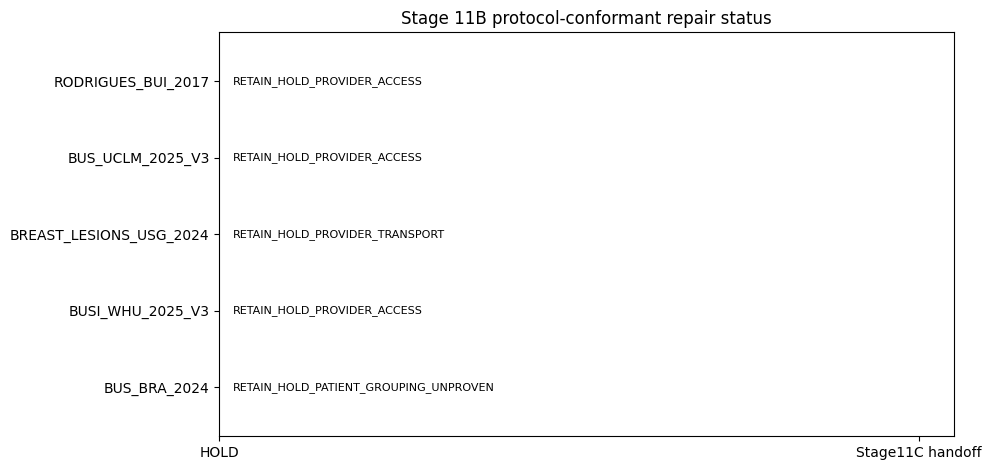


================ STAGE 11B PROTOCOL-CONFORMANT REPAIR COMPLETE ================
BUS-BRA patient grouping repaired: False
Provider routes restored (metadata/manifest only): 0 / 4
Stage11C handoff datasets: []
Source fit / Stage 12 / blind validation performed: False / False / False
Locked-blind assets touched: False
Decision: COMPLETE_STAGE11B_NO_REPAIR_READY_RETAIN_ALL_HOLDS_KEEP_STAGE11C_STAGE12_DDO2_AND_BLIND_VALIDATION_PROHIBITED
Protocol seal: f09e2b0d9505bded7329d9b380c098542cc9450b6e16d695295228da18ac67eb
Repair outcome registry hash: 494f009f6aa283e85cea95e7e98b1980483a27acdf195bc9c91152af4c2cf8e0
Stage11C handoff hash: 56f42f13993bd28125798712365b6875b6a07e4e65dcf37ff19c53bb13b738fa
Final record hash: d77c944ee88674696a069831caadd2131bc6dd6a7dad996775967694088664e3
Actual Stage 11B bytes: 92946
Next step: RETAIN_PROVIDER_AND_PATIENT_GROUPING_HOLDS_WITHOUT_SUBSTITUTION_OR_BLIND_ACCESS


In [7]:
# @title 11B-6. Seal the repair report, output manifest, final record, and replay state
import matplotlib.pyplot as plt

if REPLAY_MODE:
    final_record = verify_self_hashed_json(FINAL_RECORD_PATH, "final_record_sha256")
    output_manifest = pd.read_csv(OUTPUT_MANIFEST_PATH)
else:
    status_order = list(development_ids)
    status_values = [1 if as_bool(repair_registry.loc[repair_registry["dataset_id"].eq(dataset_id), "repair_passed"].iloc[0]) else 0 for dataset_id in status_order]
    status_labels = [str(repair_registry.loc[repair_registry["dataset_id"].eq(dataset_id), "stage11b_repair_outcome"].iloc[0]) for dataset_id in status_order]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    colors = ["#2C7A7B" if value else "#A0AEC0" for value in status_values]
    ax.barh(np.arange(len(status_order)), status_values, color=colors)
    ax.set_yticks(np.arange(len(status_order)), status_order)
    ax.set_xlim(0, 1.05)
    ax.set_xticks([0, 1], ["HOLD", "Stage11C handoff"])
    ax.set_title("Stage 11B protocol-conformant repair status")
    for index, label in enumerate(status_labels):
        ax.text(0.02 if not status_values[index] else 0.98, index, label, va="center", ha="left" if not status_values[index] else "right", fontsize=8, color="black" if not status_values[index] else "white")
    fig.tight_layout()
    fig.savefig(FIGURE_PATH, dpi=160, bbox_inches="tight", metadata={"Software": "Stage11B"})
    plt.show()

    report = f"""# Stage 11B — Protocol-Conformant Reacquisition and Patient-Grouping Repair

## Decision

`{decision}`

## Frozen boundary

- Five preassigned development datasets were retained; no role or dataset was substituted.
- BUS-BRA patient grouping was adjudicated from the official Zenodo release, released tables, archive member structure, and official author code.
- The four provider-held datasets received official metadata/manifest transport rechecks only. No image, label, or archive from those four datasets was downloaded.
- Stage 11A forbids source-axis fitting in Stage 11B; no source axis, recoverability result, transfer edge, DDO2 coefficient, Stage 12 result, or blind result was created.
- Locked-blind assets were not requested or accessed.

## Outcomes

- BUS-BRA patient grouping repaired: **{bus_bra_repaired}**.
- Provider metadata/manifest routes restored: **{provider_routes_restored}/4**.
- Exact Stage 11C handoff datasets: **{ready_ids}**.
- Independent blocker checks passed: **{int(validity['passed'].sum())}/{len(validity)}**.

## Next step

`{next_step}`
"""
    write_immutable_text(REPORT_PATH, report)

    tracked_paths = [
        PROTOCOL_SEAL_PATH, PARENT_COMMITMENT_PATH, REQUEST_AUDIT_PATH, ASSET_LEDGER_PATH,
        BUS_BRA_PROOF_PATH, BUS_BRA_MANIFEST_PATH, TRANSPORT_RECHECK_PATH, REPAIR_REGISTRY_PATH,
        STAGE11C_HANDOFF_PATH, VALIDITY_PATH, REPORT_PATH, FIGURE_PATH,
    ]
    output_manifest = pd.DataFrame([{
        "relative_path": str(path.relative_to(STAGE11B_ROOT)), "sha256": sha256_file(path), "bytes": path.stat().st_size
    } for path in tracked_paths])
    write_immutable_csv(OUTPUT_MANIFEST_PATH, output_manifest)
    tracked_bytes = int(output_manifest["bytes"].sum()) + OUTPUT_MANIFEST_PATH.stat().st_size
    assert tracked_bytes <= MAXIMUM_NEW_STAGE11B_BYTES

    final_record = {
        "stage": "Stage11B",
        "decision": decision,
        "scope": "PREASSIGNED_DEVELOPMENT_REPAIR_AND_OFFICIAL_TRANSPORT_RECHECK_ONLY_NO_SOURCE_FIT_NO_STAGE12_NO_BLIND_ACCESS",
        "parent_stage11_final_record_sha256": EXPECTED_STAGE11_FINAL_HASH,
        "parent_stage11_protocol_seal_sha256": EXPECTED_STAGE11_PROTOCOL_SEAL,
        "parent_stage11_source_summary_sha256": EXPECTED_STAGE11_SOURCE_HASH,
        "parent_stage11a_final_record_sha256": EXPECTED_STAGE11A_FINAL_HASH,
        "parent_stage11a_protocol_seal_sha256": EXPECTED_STAGE11A_PROTOCOL_SEAL,
        "parent_stage11a_action_registry_sha256": EXPECTED_STAGE11A_ACTION_HASH,
        "parent_role_registry_sha256": EXPECTED_STAGE10_ROLE_HASH,
        "stage11b_protocol_seal_sha256": protocol_seal["seal_sha256"],
        "notebook_source_sha256": notebook_source_hash,
        "bus_bra_patient_grouping_repaired": bus_bra_repaired,
        "provider_routes_restored_metadata_manifest_only": provider_routes_restored,
        "stage11c_handoff_datasets": ready_ids,
        "stage11c_authorised_for_exact_handoff_only": bool(ready_ids),
        "bus_bra_grouping_proof_sha256": sha256_file(BUS_BRA_PROOF_PATH),
        "bus_bra_repaired_manifest_sha256": sha256_file(BUS_BRA_MANIFEST_PATH),
        "transport_recheck_sha256": sha256_file(TRANSPORT_RECHECK_PATH),
        "repair_outcome_registry_sha256": sha256_file(REPAIR_REGISTRY_PATH),
        "stage11c_handoff_sha256": sha256_file(STAGE11C_HANDOFF_PATH),
        "independent_validity_checks_sha256": sha256_file(VALIDITY_PATH),
        "output_integrity_manifest_sha256": sha256_file(OUTPUT_MANIFEST_PATH),
        "tracked_stage11b_output_bytes_excluding_runtime_and_final_record": tracked_bytes,
        "maximum_new_stage11b_bytes": MAXIMUM_NEW_STAGE11B_BYTES,
        "provider_hold_images_labels_or_archives_downloaded": False,
        "bus_bra_archive_image_files_opened": False,
        "bus_bra_archive_label_files_opened": False,
        "raw_images_copied_to_drive": False,
        "source_axes_fitted": False,
        "source_recoverability_evaluated": False,
        "cross_domain_edges_evaluated": False,
        "ddo2_coefficients_fitted": False,
        "stage12_authorised": False,
        "locked_blind_assets_touched": False,
        "blind_validation_performed": False,
        "roles_changed": False,
        "datasets_substituted": False,
        "next_step": next_step,
        "completed_utc": utc_now(),
    }
    final_record["final_record_sha256"] = sha256_json(final_record)
    write_immutable_json(FINAL_RECORD_PATH, final_record)
    runtime_state.update({
        "external_requests_made": bool(len(request_audit)), "locked_blind_assets_touched": False,
        "source_axes_fitted": False, "stage12_authorised": False, "completed": True,
        "final_record_sha256": final_record["final_record_sha256"], "last_updated_utc": utc_now(),
    })
    atomic_json(RUNTIME_STATE_PATH, runtime_state)
    if BUS_BRA_TEMP.exists():
        shutil.rmtree(BUS_BRA_TEMP)

assert verify_self_hashed_json(FINAL_RECORD_PATH, "final_record_sha256")["final_record_sha256"] == final_record["final_record_sha256"]
assert sha256_file(STAGE11_SOURCE_SUMMARY_PATH) == EXPECTED_STAGE11_SOURCE_HASH
assert not any(path.suffix.lower() in {".npz", ".npy", ".pt", ".pth", ".h5", ".keras", ".pkl", ".joblib"} for path in STAGE11B_ROOT.rglob("*") if path.is_file())

print("\n================ STAGE 11B PROTOCOL-CONFORMANT REPAIR COMPLETE ================")
print("BUS-BRA patient grouping repaired:", final_record["bus_bra_patient_grouping_repaired"])
print("Provider routes restored (metadata/manifest only):", final_record["provider_routes_restored_metadata_manifest_only"], "/ 4")
print("Stage11C handoff datasets:", final_record["stage11c_handoff_datasets"])
print("Source fit / Stage 12 / blind validation performed:", final_record["source_axes_fitted"], "/", final_record["stage12_authorised"], "/", final_record["blind_validation_performed"])
print("Locked-blind assets touched:", final_record["locked_blind_assets_touched"])
print("Decision:", final_record["decision"])
print("Protocol seal:", final_record["stage11b_protocol_seal_sha256"])
print("Repair outcome registry hash:", final_record["repair_outcome_registry_sha256"])
print("Stage11C handoff hash:", final_record["stage11c_handoff_sha256"])
print("Final record hash:", final_record["final_record_sha256"])
print("Actual Stage 11B bytes:", final_record["tracked_stage11b_output_bytes_excluding_runtime_and_final_record"])
print("Next step:", final_record["next_step"])